# Chapter 4 — Training Linear Models

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.linear_model import (LinearRegression, SGDRegressor, Ridge,
                                   Lasso, ElasticNet, LogisticRegression)
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler,
                                    add_dummy_feature)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.datasets import load_iris, make_regression
from sklearn.metrics import root_mean_squared_error

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Resumen: Modelo de Regresión Lineal

## 1. Modelo lineal simple (una característica)

La satisfacción de vida se modela como una función lineal del PIB per cápita:

$$
\text{life\_satisfaction} = \theta_0 + \theta_1 \times \text{GDP\_per\_capita}
$$

Donde $\theta_0$ y $\theta_1$ son los **parámetros del modelo**.

## 2. Modelo de regresión lineal general (múltiples características)

La predicción $\hat{y}$ se calcula como una suma ponderada de las características de entrada más un sesgo (intercepto):

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

- $\hat{y}$ : valor predicho.
- $n$ : número de características.
- $x_i$ : valor de la $i$-ésima característica.
- $\theta_j$ : $j$-ésimo parámetro del modelo ($\theta_0$ es el sesgo, $\theta_1 \dots \theta_n$ son los pesos).

## 3. Forma vectorizada

El modelo puede escribirse de manera compacta usando el producto punto:

$$
\hat{y} = h_\theta(\mathbf{x}) = \boldsymbol{\theta} \cdot \mathbf{x}
$$

- $h_\theta$ : función de hipótesis parametrizada por $\boldsymbol{\theta}$.
- $\boldsymbol{\theta}$ : vector de parámetros $[\theta_0, \theta_1, \dots, \theta_n]$.
- $\mathbf{x}$ : vector de características $[x_0, x_1, \dots, x_n]$, **con $x_0 = 1$ siempre**.
- $\boldsymbol{\theta} \cdot \mathbf{x}$ : producto punto igual a $\theta_0 x_0 + \theta_1 x_1 + \cdots + \theta_n x_n$.

La función a minimizar MSE (Mean Squared Error) se define como:
$$
J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(\mathbf{x}^{(i)}) - y^{(i)})^2
$$

## The Normal Equation

La solución analítica para encontrar los parámetros $\boldsymbol{\theta}$ que minimizan la función de costo MSE es dada por la **Ecuación Normal**:
$$
\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

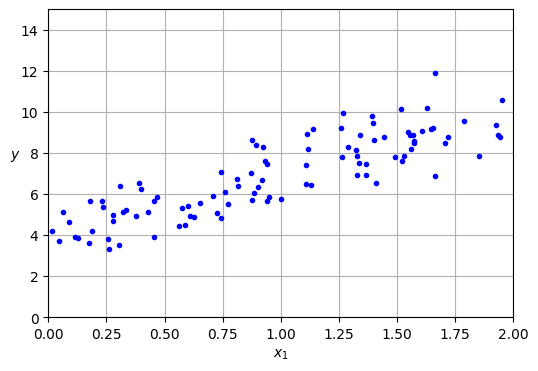

In [2]:
import numpy as np

rng = np.random.default_rng(42)
m = 100
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + ruido gaussiano

# extra code – generates Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # agrega una columna de 1s para el término de sesgo
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.94869973],
       [3.03831479]])

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.94869973],
       [10.02532931]])

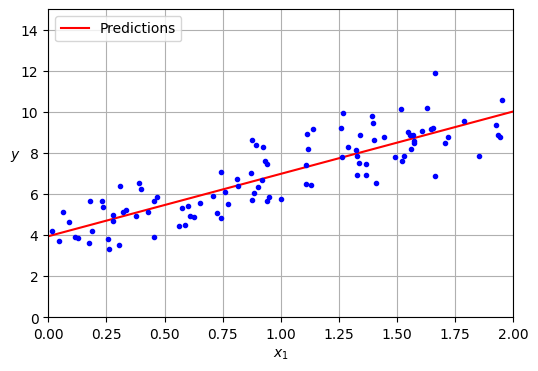

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)
lr.intercept_, lr.coef_

(array([3.94869973]), array([[3.03831479]]))

In [7]:
lr.predict(X_new)

array([[ 3.94869973],
       [10.02532931]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.94869973],
       [3.03831479]])

This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [9]:
np.linalg.pinv(X_b) @ y

array([[3.94869973],
       [3.03831479]])

# Gradient Descent
## Batch Gradient Descent

Para cada parámetro $\theta_j$ se necesita la **derivada parcial** de la función de costo (MSE) respecto a $\theta_j$:

$$
\frac{\partial}{\partial \theta_j} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^\top \mathbf{x}^{(i)} - y^{(i)} \right) x_j^{(i)}
\qquad (4\text{-}6)
$$

El **vector gradiente** agrupa todas las derivadas parciales:

$$
\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = 
\begin{bmatrix}
\frac{\partial}{\partial \theta_0} \text{MSE}(\boldsymbol{\theta}) \\
\frac{\partial}{\partial \theta_1} \text{MSE}(\boldsymbol{\theta}) \\
\vdots \\
\frac{\partial}{\partial \theta_n} \text{MSE}(\boldsymbol{\theta})
\end{bmatrix}
= \frac{2}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
\qquad (4\text{-}7)
$$

- La derivada parcial mide el cambio de la función al modificar ligeramente $\theta_j$.
- El gradiente apunta en la dirección de máximo crecimiento; se usa con signo contrario para descender.


El siguiente paso de actualización se realiza para cada iteración del algoritmo:

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta})
\qquad (4\text{-}8)
$$

In [21]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly intialized model parametes

for epoch in range(n_epochs):
    grad = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * grad

theta

array([[3.94869973],
       [3.03831479]])

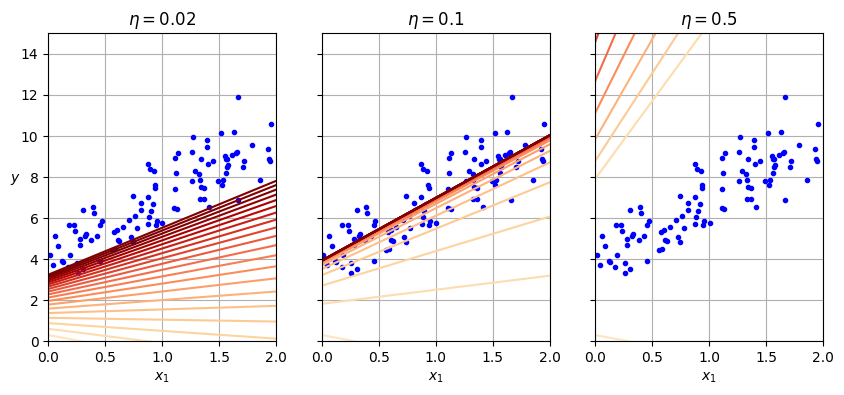

In [22]:
# extra code – generates Figure 4–8

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)

plt.show()

## Stochastic Gradient Descent (SGD)

In [24]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[3.966486  ],
       [3.04565621]])

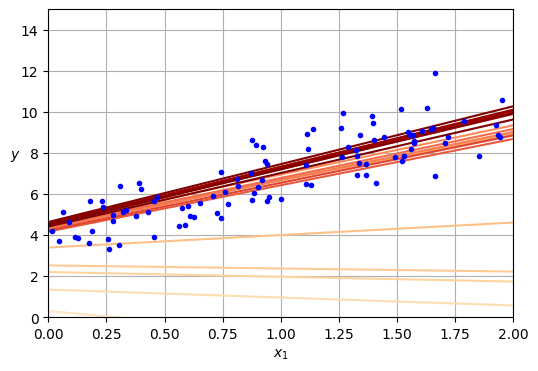

In [26]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

theta_path_sgd = []

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)  # learning rate
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [28]:
from sklearn.linear_model import SGDRegressor

sdg_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.1,
                        n_iter_no_change=100, random_state=42)

sdg_reg.fit(X, y.ravel())
sdg_reg.intercept_, sdg_reg.coef_

(array([3.92760553]), array([3.00157861]))

## Mini-batch gradient descent

The code in this section is used to generate the next figure, it is not in the book.

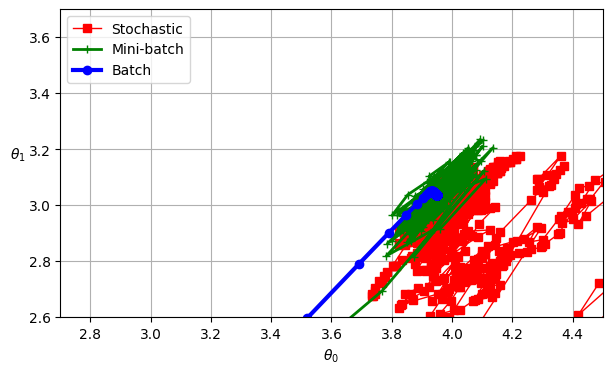

In [32]:
# extra code – this cell generates Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.7, 4.5, 2.6, 3.7])
plt.grid()

plt.show()

## Polynomial regression

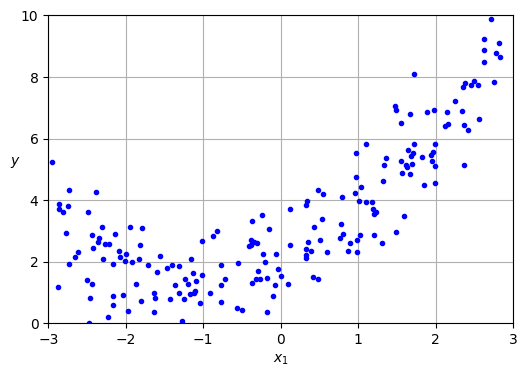

In [33]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

# plot 
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()


In [37]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly[:5]

array([[ 1.64373629,  2.701869  ],
       [-0.36672936,  0.13449042],
       [ 2.15158752,  4.62932885],
       [ 1.18420817,  1.402349  ],
       [-2.43493591,  5.9289129 ]])

In [38]:
X[:5]

array([[ 1.64373629],
       [-0.36672936],
       [ 2.15158752],
       [ 1.18420817],
       [-2.43493591]])

In [39]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_


(array([2.00540719]), array([[1.11022126, 0.50526985]]))

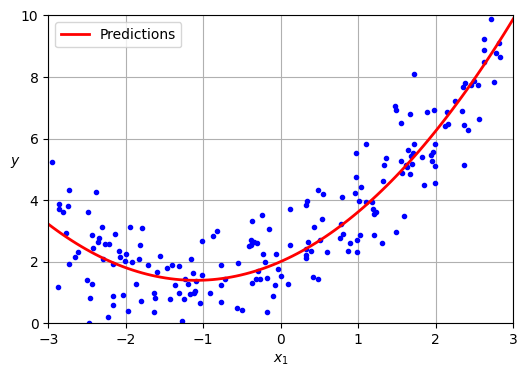

In [40]:
# extra code – this cell generates Figure 4–13

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()